# EDA Afluencia del Metro de la Ciudad de México (2025)

In [72]:
# Importando librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.dates as mdates

In [55]:
# Dataframe histórico de 2010 a 2025
url = 'https://github.com/AndrsGzRo/prediccion-afluencia-metrocdmx/raw/refs/heads/main/Data/processed/afluencia_metro_2010_2025.zip'
df = pd.read_csv(url,compression='zip')

# Dataframe de 2025
df_2025 = (
    df[df['anio'] == 2025]
)
df_2025['fecha'] = pd.to_datetime(df_2025['fecha'])

/tmp/ipython-input-866251227.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_2025['fecha'] = pd.to_datetime(df_2025['fecha'])


## Panorama general 2025

## Afluencia Diaria en 2025

In [56]:
# Tema de Seaborn
sns.set_theme(style='darkgrid')

# Colores del Metro
metro_color = '#FE5000'
colores_metro = {
    'Línea 1':'#F04E98',
    'Línea 2':'#005EB8',
    'Línea 3':'#AF9800',
    'Línea 4':'#6BBBAE',
    'Línea 5':'#FFD100',
    'Línea 6':'#DA291C',
    'Línea 7':'#E87722',
    'Línea 8':'#009444',
    'Línea 9':'#512F2E',
    'Línea A':'#981D97',
    'Línea B':'#B1B3B3',
    'Línea 12':'#B0A32A'
}


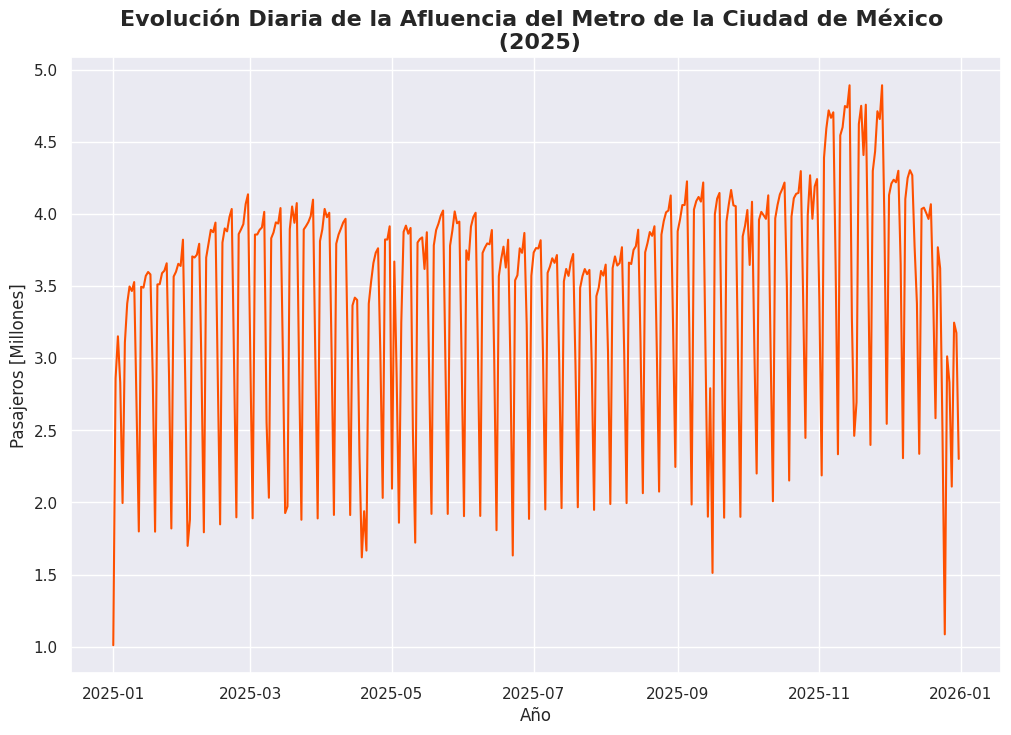

In [57]:
# Dataframe de la Afluencia por Día en 2025
afluencia_2025 = (
    df_2025.groupby('fecha')['afluencia']
    .sum().reset_index()
)
afluencia_2025['afluencia_mill'] = afluencia_2025['afluencia'] / 1e6
plt.figure(figsize=(12,8))
sns.lineplot(
    data=afluencia_2025,
    x='fecha',
    y='afluencia_mill',
    color=metro_color
)
plt.xlabel('Año')
plt.ylabel('Pasajeros [Millones]')
plt.title('Evolución Diaria de la Afluencia del Metro de la Ciudad de México \n (2025)',
          fontsize=16,fontweight='bold')
plt.show()

### Media móvil 7 días

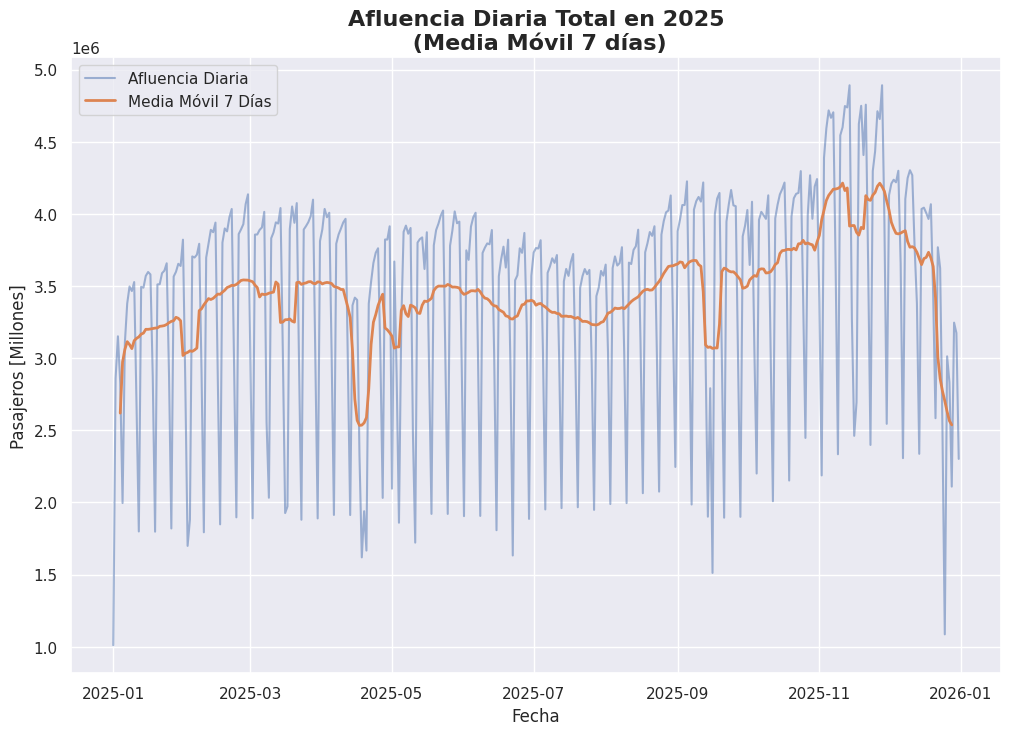

In [58]:
afluencia_2025 = (
    df_2025.groupby('fecha')['afluencia']
    .sum().sort_index()
    )
media_7 = afluencia_2025.rolling(window=7,center=True).mean()

plt.figure(figsize=(12,8))
sns.lineplot(
    x=afluencia_2025.index,
    y=afluencia_2025.values,
    alpha=0.5,
    label='Afluencia Diaria'
)
sns.lineplot(
    x=media_7.index,
    y=media_7.values,
    linewidth=2,
    label='Media Móvil 7 Días'
)
plt.xlabel('Fecha')
plt.ylabel('Pasajeros [Millones]')
plt.title('Afluencia Diaria Total en 2025\n (Media Móvil 7 días)',fontsize=16,
          fontweight='bold')
plt.show()

## Análisis por Línea

### Afluencia por Línea

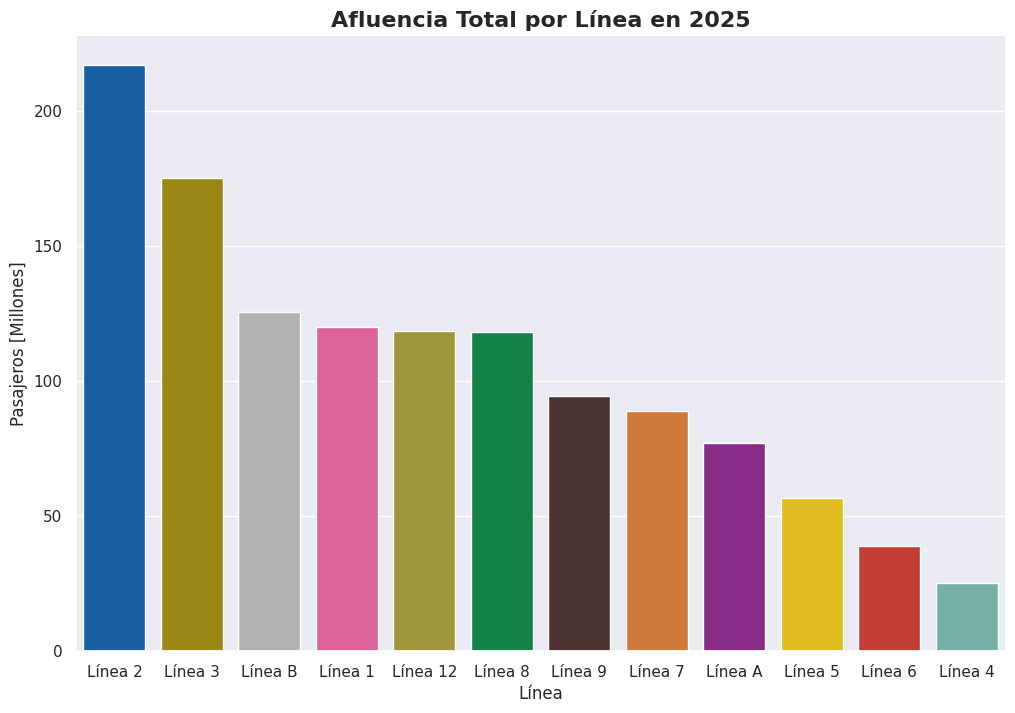

In [59]:
linea_total = (
    df_2025.groupby('linea')['afluencia']
    .sum().reset_index()
    .sort_values(by='afluencia',ascending=False)
)
# Afluencia en Millones
linea_total['afluencia_mill'] = linea_total['afluencia'] / 1e6
plt.figure(figsize=(12,8))
sns.barplot(
    data=linea_total,
    x='linea',
    y='afluencia_mill',
    palette=colores_metro,
    hue='linea'
)
plt.xlabel('Línea')
plt.ylabel('Pasajeros [Millones]')
plt.title('Afluencia Total por Línea en 2025',fontsize=16,fontweight='bold')
plt.show()

### Boxplot por Línea

<Axes: xlabel='linea', ylabel='afluencia'>

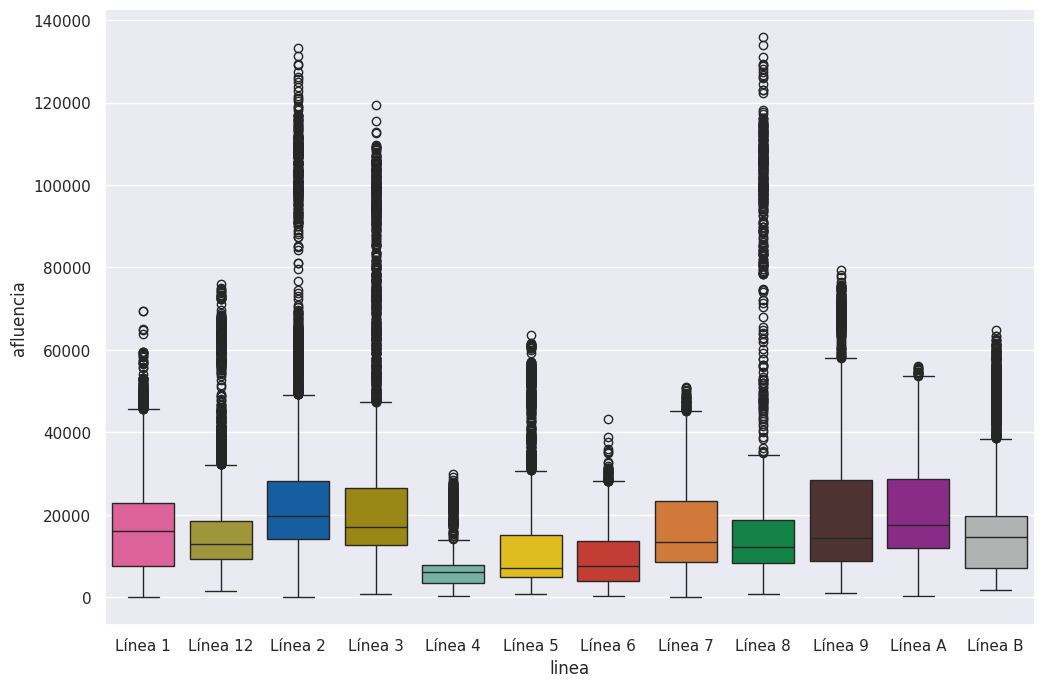

In [60]:
plt.figure(figsize=(12,8))
sns.boxplot(
    data=df_2025,
    x='linea',
    y='afluencia',
    palette=colores_metro,
    hue='linea'
)

/tmp/ipython-input-1761148672.py:21: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(['linea','dia_semana'])['afluencia']


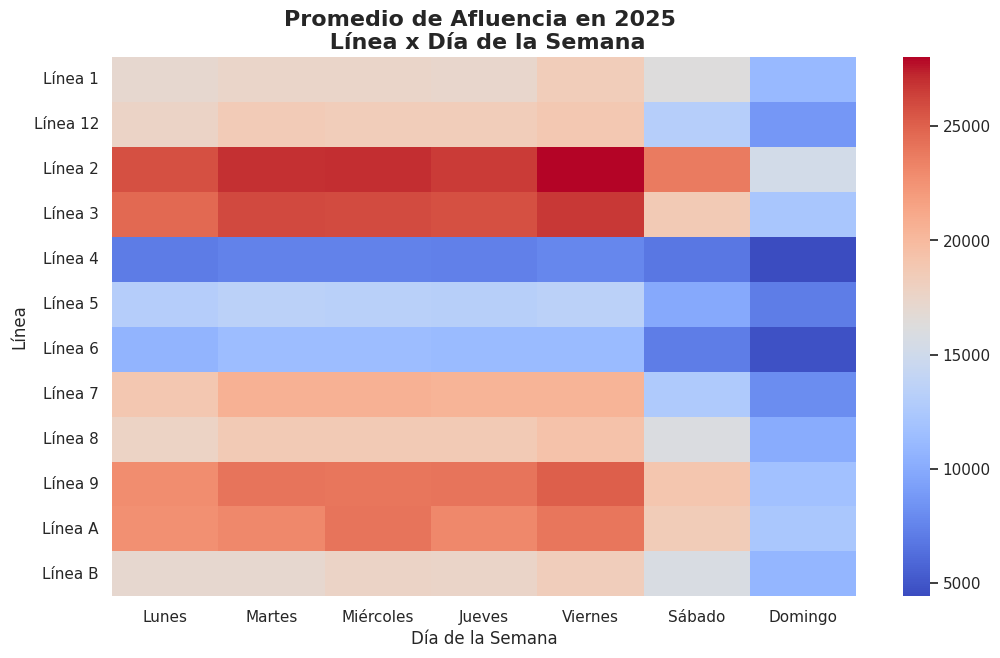

In [61]:
df_2025 = df_2025.copy()
df_2025['dia_semana'] = df_2025['fecha'].dt.day_name()
df_2025['dia_semana'] = df_2025['dia_semana'].replace({
    'Monday':'Lunes',
    'Tuesday':'Martes',
    'Wednesday':'Miércoles',
    'Thursday':'Jueves',
    'Friday':'Viernes',
    'Saturday':'Sábado',
    'Sunday':'Domingo'
})
orden = ['Lunes','Martes','Miércoles','Jueves','Viernes','Sábado','Domingo']
df_2025['dia_semana'] = pd.Categorical(
    df_2025['dia_semana'],
    categories=orden,
    ordered=True)

# Heatmap
heat = (
    df_2025
    .groupby(['linea','dia_semana'])['afluencia']
    .mean().reset_index()
)
pivot = heat.pivot(
    index='linea',
    columns='dia_semana',
    values='afluencia'
)

# Visualización
plt.figure(figsize=(12,7))
sns.heatmap(
    pivot,
    cmap='coolwarm'
)
plt.xlabel('Día de la Semana')
plt.ylabel('Línea')
plt.title('Promedio de Afluencia en 2025 \n Línea x Día de la Semana',
          fontsize=16,fontweight='bold')
plt.show()

<Figure size 2000x1200 with 0 Axes>

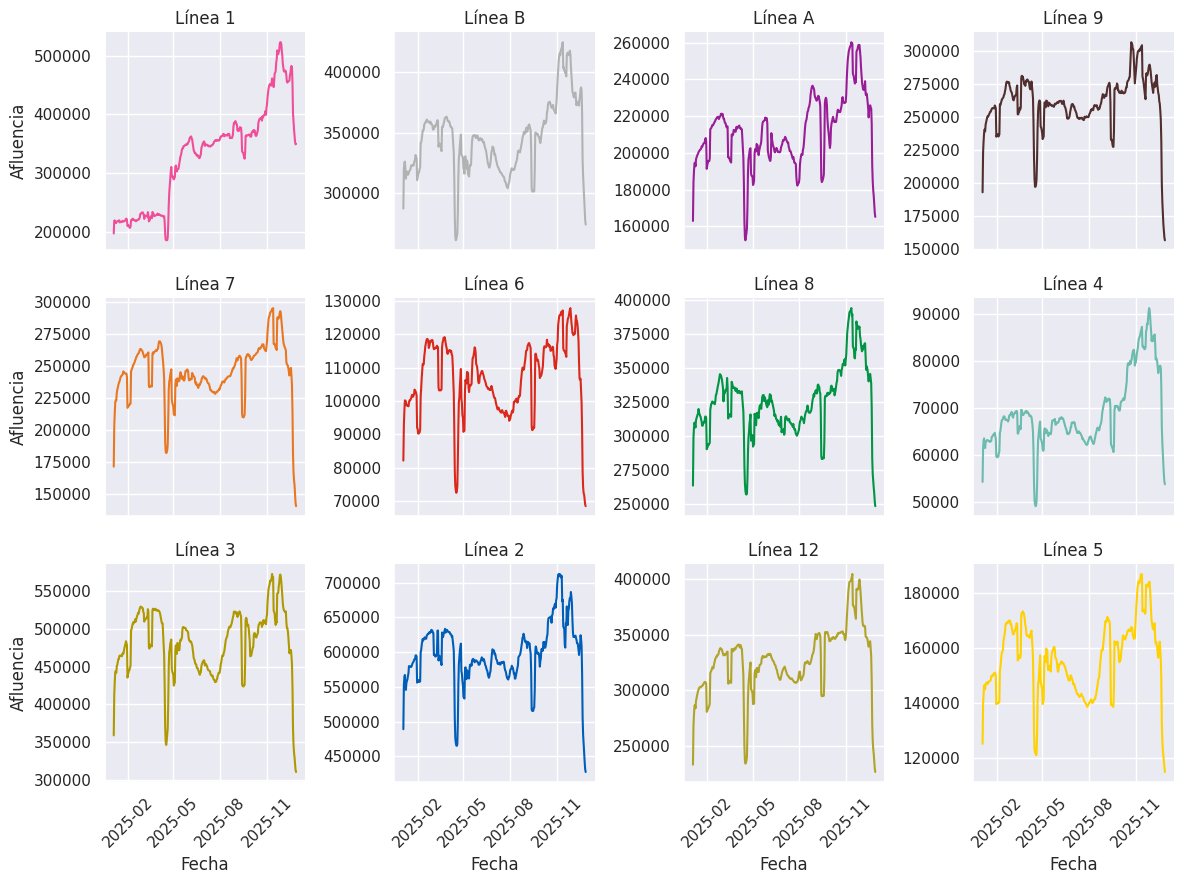

In [78]:
# Afluencia por Línea
diario_linea = (
    df_2025
    .groupby(['fecha','linea'])['afluencia']
    .sum().reset_index()
    .sort_values(by='fecha')
)

diario_linea['media_7'] = (
    diario_linea
    .groupby('linea')['afluencia']
    .transform(lambda x:x.rolling(7,center=True).mean())
)

# Figura
plt.figure(figsize=(20,12))

g = sns.FacetGrid(
    diario_linea,
    col='linea',
    col_wrap=4,
    height=3,
    sharey=False
)
for ax, linea in zip(g.axes.flat, diario_linea['linea'].unique()):
    data = diario_linea[diario_linea['linea'] == linea]

    sns.lineplot(
        data=data,
        x='fecha',
        y='media_7',
        color=colores_metro[linea],
        ax=ax
    )
    ax.set_title(linea)

# Rotar fechas
for ax in g.axes.flat:
    ax.tick_params(axis='x',rotation=45)
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))

g.set_axis_labels('Fecha', 'Afluencia')
plt.tight_layout()
plt.show()

## Análisis por Estación

### Top 15 Estaciones

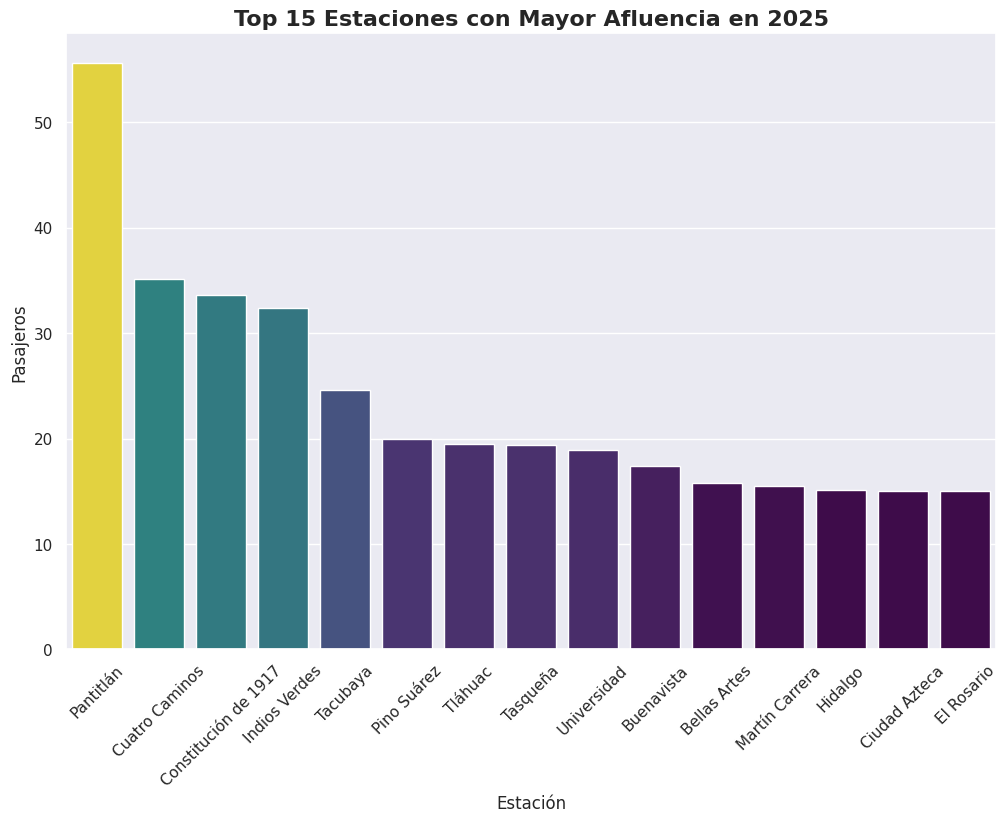

In [90]:
estaciones = (
    df_2025
    .groupby('estacion')['afluencia']
    .sum().reset_index()
    .sort_values(by='afluencia',ascending=False)
    .head(15)
)
estaciones['afluencia_mill'] = estaciones['afluencia'] / 1e6
# Visualización
plt.figure(figsize=(12,8))
sns.barplot(
    data=estaciones,
    x='estacion',
    y='afluencia_mill',
    palette='viridis',
    hue='afluencia',
    legend=False
)
plt.xlabel('Estación')
plt.xticks(rotation=45)
plt.ylabel('Pasajeros')
plt.title('Top 15 Estaciones con Mayor Afluencia en 2025',fontsize=16,fontweight='bold')
plt.show()

### Distribución de la Afluencia de las Estaciones

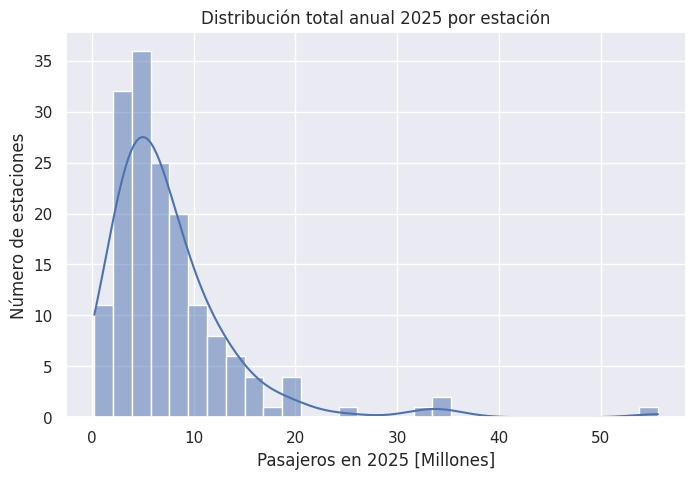

In [101]:
# Afluencia de todas las estaciones en el año 2025
afluencia_estacion = (
    df_2025
    .groupby('estacion')['afluencia']
    .sum()
    .reset_index()
)

afluencia_estacion['afluencia_mill'] = afluencia_estacion['afluencia'] / 1e6
# Visualización
plt.figure(figsize=(8,5))

sns.histplot(
    afluencia_estacion['afluencia_mill'],
    bins=30,
    kde=True,
)

plt.title('Distribución total anual 2025 por estación')
plt.xlabel('Pasajeros en 2025 [Millones]')
plt.ylabel('Número de estaciones')
plt.show()

## Ranking de Estaciones (Mensual)

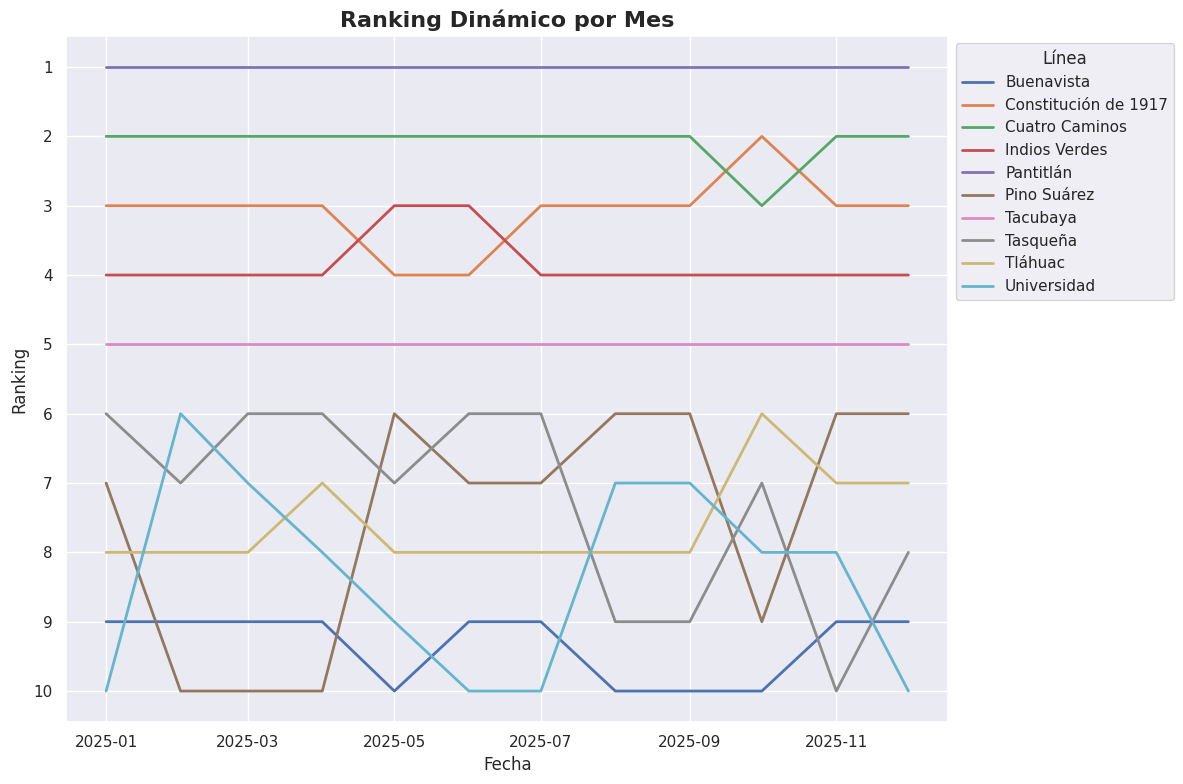

In [148]:
df_2025['fecha'] = pd.to_datetime(df_2025['fecha'])
df_2025['mes'] = df_2025['fecha'].dt.to_period('M')
top_n = 10
top_estaciones = (
    df_2025
    .groupby('estacion')['afluencia']
    .sum()
    .sort_values(ascending=False)
    .head(top_n)
    .index
)

# Filtrando
df_filtrado = df_2025[df_2025['estacion'].isin(top_estaciones)]

# Ranking dinámico
df_daily = (
    df_filtrado
    .groupby(['mes','estacion'])['afluencia']
    .sum().reset_index()
)
df_daily['mes'] = df_daily['mes'].dt.to_timestamp()

df_daily['rank'] = (
    df_daily
    .groupby('mes')['afluencia']
    .rank(ascending=False,method='first')
)

plt.figure(figsize=(12,8))
sns.lineplot(
    data=df_daily,
    x='mes',
    y='rank',
    hue='estacion',
    linewidth=2
    )
plt.gca().invert_yaxis()
plt.xlabel('Fecha')
plt.ylabel('Ranking')
plt.yticks(sorted(df_daily['rank'].unique()))
plt.title('Ranking Dinámico por Mes',fontsize=16,fontweight='bold')
plt.legend(
    title='Línea',
    bbox_to_anchor=(1, 1),
    loc='upper left'
)
plt.tight_layout()
plt.show()